# Predicting the Most Likely Condition for a Prescription

In this notebook I am building a classification model that predicts which condition category a prescription is most likely being used to treat, based on the drug itself and the patient's demographic details. I am using the cleaned, merged MEPS 2023 dataset (`cleaned_prescriptions_merged.csv`) that I produced from my Power Query pipeline.

I am restricting this to the 8 most common condition categories in the dataset (I explain why in Section 2), so this model predicts which of those 8 categories a prescription most likely belongs to, rather than trying to cover every possible condition.

My goal here is to add a predictive angle on top of the descriptive analysis I already did in the Power BI dashboard, and to see whether prescribing patterns and demographics actually carry enough signal to guess the general condition a drug is being prescribed for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### **1. Loading and Exploring the Data**

This is the final labelled table from my Power BI data model. Each row represents one prescription linked to one condition, so if a prescription was linked to more than one diagnosed condition, it shows up as more than one row. I noticed this while building the dashboard, it comes from how MEPS links prescriptions to conditions, and I already accounted for it there.

In [2]:
# reading in the cleaned dataset
df = pd.read_csv("../data/cleaned_prescriptions_merged.csv")
print("Shape:", df.shape)
df.head()

Shape: (204534, 16)


,DUPERSID,RXNAME,RXFORM,RXDAYSUP,PERWT23F,ICD10CDX,ICD10CDX LABEL,AGE23X,SEX,FAMINC23,Age Group,Gender,Family Income Group,RXRECIDX,CCSR1X,CCSR1X LABEL
0,2790141101,LISINOPRIL,TABS,90.0,4137.563829,I10,ESSENTIAL (PRIMARY) HYPERTENSION,83.0,1,28524.0,50+,Male,20k–49k,2790141101001403001,CIR007,ESSENTIAL HYPERTENSION
1,2790141101,LISINOPRIL,TABS,90.0,4137.563829,I10,ESSENTIAL (PRIMARY) HYPERTENSION,83.0,1,28524.0,50+,Male,20k–49k,2790141101001403002,CIR007,ESSENTIAL HYPERTENSION
2,2790172102,LISINOPRIL,TABS,90.0,15713.198468,I10,ESSENTIAL (PRIMARY) HYPERTENSION,69.0,1,28781.0,50+,Male,20k–49k,2790172102008303001,CIR007,ESSENTIAL HYPERTENSION
3,2790483101,LISINOPRIL,TABS,90.0,7841.341449,I10,ESSENTIAL (PRIMARY) HYPERTENSION,68.0,1,32794.0,50+,Male,20k–49k,2790483101002303001,CIR007,ESSENTIAL HYPERTENSION
4,2790483101,LISINOPRIL,TABS,90.0,7841.341449,I10,ESSENTIAL (PRIMARY) HYPERTENSION,68.0,1,32794.0,50+,Male,20k–49k,2790483101002403001,CIR007,ESSENTIAL HYPERTENSION


In [3]:
# getting an overview of column types and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204534 entries, 0 to 204533
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DUPERSID             204534 non-null  int64  
 1   RXNAME               204534 non-null  object 
 2   RXFORM               204534 non-null  object 
 3   RXDAYSUP             148861 non-null  float64
 4   PERWT23F             204534 non-null  float64
 5   ICD10CDX             196483 non-null  object 
 6   ICD10CDX LABEL       204534 non-null  object 
 7   AGE23X               203685 non-null  float64
 8   SEX                  204534 non-null  int64  
 9   FAMINC23             204525 non-null  float64
 10  Age Group            204534 non-null  object 
 11  Gender               204534 non-null  object 
 12  Family Income Group  204534 non-null  object 
 13  RXRECIDX             204534 non-null  int64  
 14  CCSR1X               196483 non-null  object 
 15  CCSR1X LABEL     

I want to check for missing values before going further. `RXDAYSUP`, `ICD10CDX`/`CCSR1X`, and `AGE23X`/`FAMINC23` all have some missing values, this is expected since MEPS uses reserved codes for inapplicable or not ascertained responses, and I already converted those to null during the Power Query cleaning stage.

In [4]:
# checking which columns still have missing values after the earlier cleaning stage
df.isnull().sum()

DUPERSID                   0
RXNAME                     0
RXFORM                     0
RXDAYSUP               55673
PERWT23F                   0
ICD10CDX                8051
ICD10CDX LABEL             0
AGE23X                   849
SEX                        0
FAMINC23                   9
Age Group                  0
Gender                     0
Family Income Group        0
RXRECIDX                   0
CCSR1X                  8051
CCSR1X LABEL               0
dtype: int64

### **2. Defining the Prediction Target**

The raw `ICD10CDX` field has hundreds of distinct diagnosis codes, and most of them only occur a handful of times in the sample. That makes it a poor target to predict directly, since the model would barely have any examples to learn from for most codes. The `CCSR1X LABEL` field groups these into broader, clinically meaningful condition categories, so I am using that as my target instead.

I initially tried bucketing the top 20 CCSR categories and grouping everything else into an `"OTHER"` class. When I looked at the results, `OTHER` turned out to be the single biggest and messiest class, it was a mix of around 176 unrelated conditions with no consistent drug pattern behind them, and it was pulling my overall performance down without actually telling me anything useful. So instead I am restricting the target to the top 8 most frequent CCSR categories only, and dropping every other row rather than lumping them into a catch all class. This means I lose coverage of the rarer conditions, but I get a target that is both common enough and coherent enough for the model to actually learn from. I am also dropping rows labelled `"CANNOT BE COMPUTED"`, which is MEPS's placeholder for a missing or unmatched diagnosis code, since there is no real label to predict there.

In [5]:
# dropping rows where there is no real condition label to predict
model_df = df[df["CCSR1X LABEL"] != "CANNOT BE COMPUTED"].copy()

# keeping only the 8 most frequent CCSR categories and dropping the rest
top_categories = model_df["CCSR1X LABEL"].value_counts().head(8).index
model_df = model_df[model_df["CCSR1X LABEL"].isin(top_categories)].copy()
model_df["condition_target"] = model_df["CCSR1X LABEL"]

print(f"Rows before filtering: {len(df):,}")
print(f"Rows after restricting to top 8 categories: {len(model_df):,}")
print(f"Number of target classes: {model_df['condition_target'].nunique()}")

Rows before filtering: 204,534
Rows after restricting to top 8 categories: 99,999
Number of target classes: 8


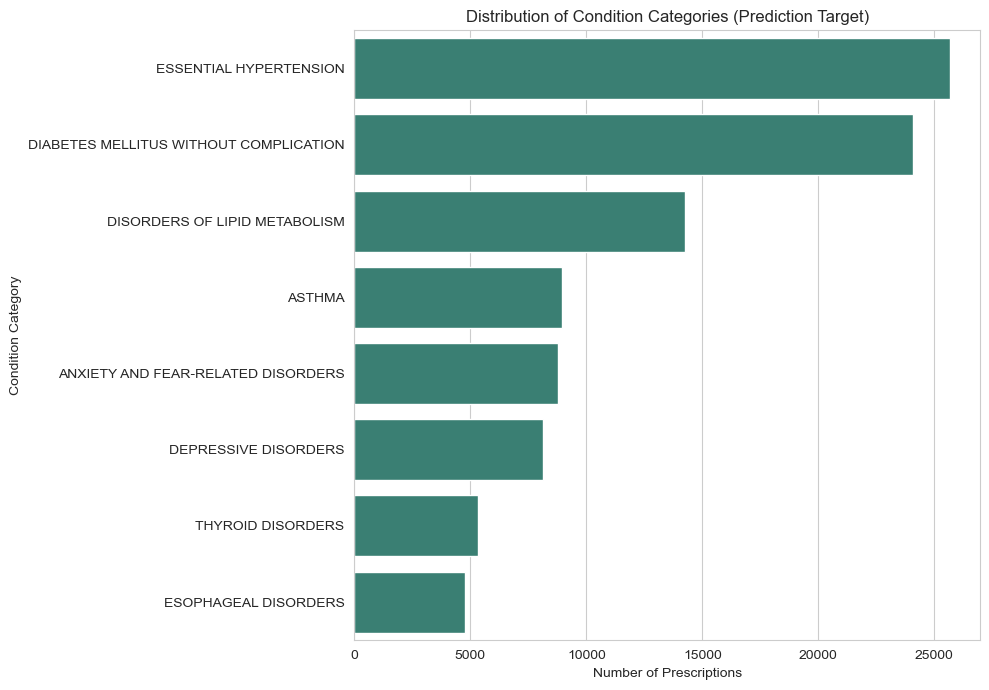

In [6]:
# plotting how many prescriptions fall into each of the 8 target categories
plt.figure(figsize=(10, 7))
order = model_df["condition_target"].value_counts().index
sns.countplot(data=model_df, y="condition_target", order=order, color="#2E8B7A")
plt.title("Distribution of Condition Categories (Prediction Target)")
plt.xlabel("Number of Prescriptions")
plt.ylabel("Condition Category")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()

In [7]:
# checking the exact counts behind the chart above
model_df["condition_target"].value_counts()

condition_target
ESSENTIAL HYPERTENSION                    25684
DIABETES MELLITUS WITHOUT COMPLICATION    24090
DISORDERS OF LIPID METABOLISM             14238
ASTHMA                                     8939
ANXIETY AND FEAR-RELATED DISORDERS         8797
DEPRESSIVE DISORDERS                       8134
THYROID DISORDERS                          5334
ESOPHAGEAL DISORDERS                       4783
Name: count, dtype: int64

Looking at the counts, the target is still imbalanced, Essential Hypertension and Diabetes Mellitus Without Complication are the two largest categories by a fair margin. That lines up with what I already saw in my dashboard, both conditions are extremely common in prescribing data generally, so I am not surprised to see the same pattern here. The important difference from my earlier attempt is that all 8 classes are now real, distinct conditions rather than one of them being a dumping ground for everything else, which should make both training and evaluating the model more meaningful.

### **3. Feature Engineering**

I am using five features to predict the condition category: the drug name, the drug form, and the patient's age group, gender, and family income group.

`RXNAME` has 1,551 distinct values on its own, and most of them barely show up in the data. If I one hot encoded that directly I would end up with hundreds of mostly empty columns. `RXFORM` has the same issue to a smaller degree. I am handling both the same way I handled the target, keeping the most frequent values as they are and grouping everything else into `"OTHER"`.

One thing I had to be careful about here, I only decide which drugs and forms count as "most frequent" using the training data, after the split, not the full dataset. If I did this before splitting, information from the test set would leak into my feature engineering and my evaluation would look better than it actually is. That is why the bucketing step happens after the train and test split below, not before it.

In [8]:
# keeping the raw columns for now, bucketing happens after the split
feature_cols_raw = ["RXNAME", "RXFORM", "Age Group", "Gender", "Family Income Group"]
target_col = "condition_target"

X_raw = model_df[feature_cols_raw]
y = model_df[target_col]
groups = model_df["DUPERSID"]  # need this for the patient grouped split below

print("Raw feature preview:")
X_raw.head()

Raw feature preview:


,RXNAME,RXFORM,Age Group,Gender,Family Income Group
0,LISINOPRIL,TABS,50+,Male,20k–49k
1,LISINOPRIL,TABS,50+,Male,20k–49k
2,LISINOPRIL,TABS,50+,Male,20k–49k
3,LISINOPRIL,TABS,50+,Male,20k–49k
4,LISINOPRIL,TABS,50+,Male,20k–49k


### **4. Train and Test Split**

Since each row is a prescription linked to a condition, one patient can end up contributing several rows, either from separate prescriptions, or from a single prescription being linked to more than one of my 8 target conditions. If I split randomly by row, some of a patient's rows could end up in training and others in the test set, which means the model could partly be learning that specific patient's pattern rather than genuinely generalising.

To avoid that, I am splitting using `GroupShuffleSplit`, grouped by `DUPERSID`, so every row belonging to the same patient stays entirely in either the training set or the test set, never split across both. This means the classes are not perfectly balanced between train and test anymore, but I think that is a fair trade for a split that actually tests how the model performs on patients it has never seen.

In [9]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_raw, y, groups=groups))

X_train_raw, X_test_raw = X_raw.iloc[train_idx].copy(), X_raw.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training set: {X_train_raw.shape[0]:,} rows, {groups.iloc[train_idx].nunique():,} unique patients")
print(f"Test set: {X_test_raw.shape[0]:,} rows, {groups.iloc[test_idx].nunique():,} unique patients")

# double checking that no patient appears on both sides of the split
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Patients appearing in both sets: {len(overlap)}")

Training set: 79,292 rows, 6,320 unique patients
Test set: 20,707 rows, 1,581 unique patients
Patients appearing in both sets: 0


### **5. Bucketing Drug Name and Drug Form**

Now that the split is done, I am identifying the most frequent drug names and forms using only the training set, and applying that same mapping to both the training and test sets. Anything in the test set that was not common enough to make the training set's top list gets mapped to `"OTHER"`, the same way a genuinely new drug would be handled if this model were used on new prescriptions later.

In [10]:
# working out the top drugs and forms from the training set only, not the full dataset
top_drugs = X_train_raw["RXNAME"].value_counts().head(100).index
top_forms = X_train_raw["RXFORM"].value_counts().head(15).index

print(f"Top 100 drugs cover {X_train_raw['RXNAME'].isin(top_drugs).mean():.1%} of the training set")
print(f"Top 15 forms cover {X_train_raw['RXFORM'].isin(top_forms).mean():.1%} of the training set")

def bucket_features(X):
    # applying the training set's top drug/form lists to whichever dataframe is passed in
    X = X.copy()
    X["drug_bucketed"] = np.where(X["RXNAME"].isin(top_drugs), X["RXNAME"], "OTHER")
    X["form_bucketed"] = np.where(X["RXFORM"].isin(top_forms), X["RXFORM"], "OTHER")
    return X[["drug_bucketed", "form_bucketed", "Age Group", "Gender", "Family Income Group"]]

X_train = bucket_features(X_train_raw)
X_test = bucket_features(X_test_raw)

feature_cols = ["drug_bucketed", "form_bucketed", "Age Group", "Gender", "Family Income Group"]

print("\nFinal training feature preview:")
X_train.head()

Top 100 drugs cover 86.7% of the training set
Top 15 forms cover 96.0% of the training set

Final training feature preview:


,drug_bucketed,form_bucketed,Age Group,Gender,Family Income Group
0,LISINOPRIL,TABS,50+,Male,20k–49k
1,LISINOPRIL,TABS,50+,Male,20k–49k
2,LISINOPRIL,TABS,50+,Male,20k–49k
3,LISINOPRIL,TABS,50+,Male,20k–49k
4,LISINOPRIL,TABS,50+,Male,20k–49k


### **6. Preprocessing and Model Pipelines**

All five of my features are categorical, so I am one hot encoding them. I wrapped this in a `ColumnTransformer` and combined it with each classifier in a `Pipeline`, so the same encoding gets applied consistently across both models without me repeating the same code twice.

I am comparing two models:
- **Logistic Regression**, as a simple linear baseline
- **Random Forest**, which can capture non linear interactions between features, for example a particular drug being more strongly linked to a condition only within a specific age group

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols)
    ]
)

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1))
])

# fitting both pipelines on the training data
log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


Before comparing the two trained models, I wanted a naive baseline to check against, a classifier that just always predicts whichever class is most common in the training data. If my real models cannot clearly beat this, that would mean they are not actually learning anything useful from the features, they would just be riding the class imbalance.

In [12]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Majority class baseline accuracy: {baseline_acc:.3f}")
print(f"(always predicting '{y_train.mode()[0]}')")

Majority class baseline accuracy: 0.256
(always predicting 'ESSENTIAL HYPERTENSION')


### **7. Model Evaluation**

I am evaluating both models on the held out test set using accuracy and F1 score. I am reporting two versions of F1, weighted F1, which I am using as my main metric for picking the better model since it accounts for the class sizes, and macro F1, which averages across all 8 classes equally regardless of size. Weighted F1 still leans towards the bigger classes, so I included macro F1 specifically to show how the model does across classes more evenly, the per class breakdown below shows this gap directly, since some categories score noticeably better than others.

In [13]:
results = {}

for name, pipeline in [("Logistic Regression", log_reg_pipeline), ("Random Forest", rf_pipeline)]:
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1_weighted = f1_score(y_test, preds, average="weighted")
    f1_macro = f1_score(y_test, preds, average="macro")
    results[name] = {
        "accuracy": acc, "f1_weighted": f1_weighted, "f1_macro": f1_macro,
        "predictions": preds, "pipeline": pipeline
    }
    print(f"{name}: accuracy = {acc:.3f}, weighted F1 = {f1_weighted:.3f}, macro F1 = {f1_macro:.3f}")

# using weighted F1 as my main criterion for picking the better model
best_model_name = max(results, key=lambda m: results[m]["f1_weighted"])
print(f"\nBest performing model (by weighted F1): {best_model_name}")
print(f"Improvement over majority class baseline: {results[best_model_name]['accuracy'] - baseline_acc:+.3f} accuracy")

Logistic Regression: accuracy = 0.802, weighted F1 = 0.800, macro F1 = 0.784
Random Forest: accuracy = 0.753, weighted F1 = 0.748, macro F1 = 0.741

Best performing model (by weighted F1): Logistic Regression
Improvement over majority class baseline: +0.546 accuracy


I am using whichever model performed better on weighted F1 for the more detailed evaluation below.

In [14]:
best_preds = results[best_model_name]["predictions"]
best_pipeline = results[best_model_name]["pipeline"]
print(classification_report(y_test, best_preds, zero_division=0))

                                        precision    recall  f1-score   support

    ANXIETY AND FEAR-RELATED DISORDERS       0.67      0.46      0.55      1916
                                ASTHMA       0.83      0.80      0.81      1481
                  DEPRESSIVE DISORDERS       0.54      0.65      0.59      1655
DIABETES MELLITUS WITHOUT COMPLICATION       0.92      0.78      0.84      5368
         DISORDERS OF LIPID METABOLISM       0.89      0.86      0.87      2895
                  ESOPHAGEAL DISORDERS       0.89      0.88      0.88      1007
                ESSENTIAL HYPERTENSION       0.75      0.94      0.84      5307
                     THYROID DISORDERS       0.93      0.86      0.89      1078

                              accuracy                           0.80     20707
                             macro avg       0.80      0.78      0.78     20707
                          weighted avg       0.81      0.80      0.80     20707



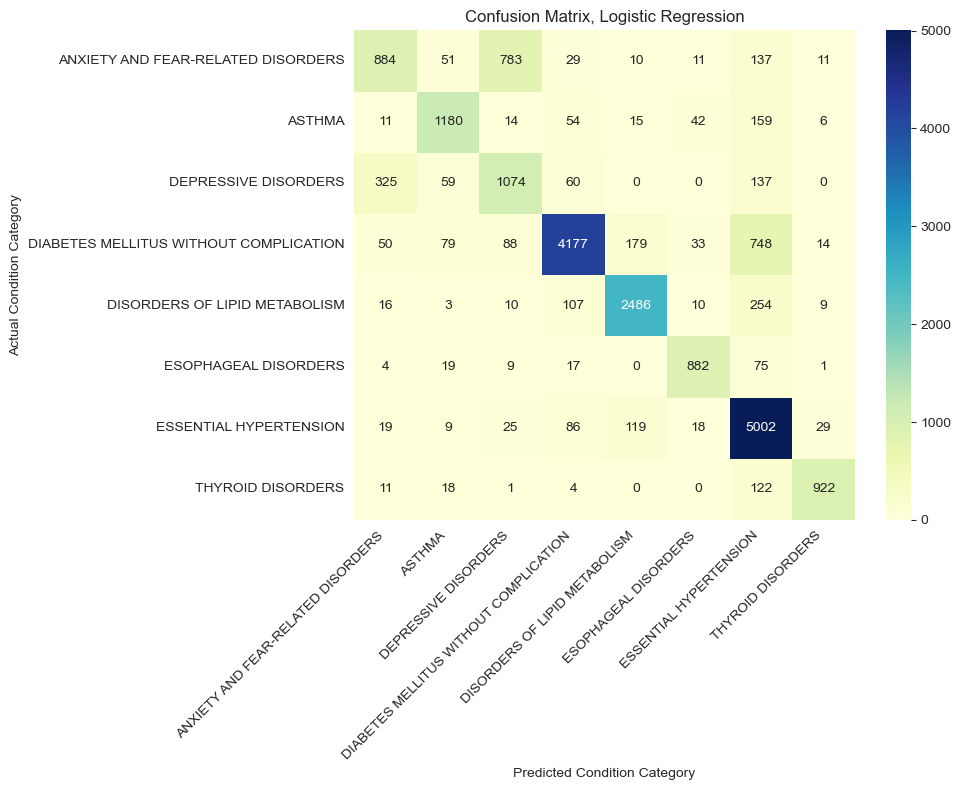

In [15]:
# building the confusion matrix for the best performing model
cm_labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_preds, labels=cm_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, xticklabels=cm_labels, yticklabels=cm_labels, cmap="YlGnBu", annot=True, fmt="d")
plt.title(f"Confusion Matrix, {best_model_name}")
plt.xlabel("Predicted Condition Category")
plt.ylabel("Actual Condition Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

With only 8 well represented condition categories and no catch all class left in, this confusion matrix is much easier to actually read than my earlier 21 class version. I can see clearly where the model gets confused between specific pairs of conditions, instead of that being buried somewhere in a large, noisy grid.

### **8. Feature Importance**

How I pull out feature importance depends on which model won. Random Forest gives me `feature_importances_` directly, while for Logistic Regression I am using the average absolute size of its coefficients across the classes it fits internally for a multi class problem. Either way, I am grouping the importances back up to the original feature categories, drug, form, age group, gender, and income group, so I can see which factor the model actually relied on most.

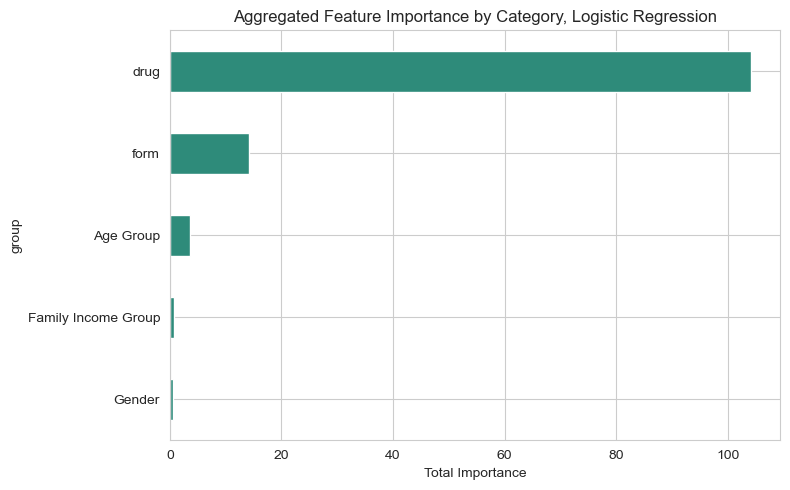

group
drug                   104.128838
form                    14.247989
Age Group                3.582921
Family Income Group      0.708702
Gender                   0.653729
Name: importance, dtype: float64

In [16]:
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
classifier = best_pipeline.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
else:
    # for Logistic Regression, averaging the absolute coefficient size across classes
    importances = np.abs(classifier.coef_).mean(axis=0)

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})

# grouping the one hot encoded columns back to their original feature category
importance_df["group"] = importance_df["feature"].str.extract(r"cat__(.*?)_")[0]
grouped_importance = importance_df.groupby("group")["importance"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
grouped_importance.plot(kind="barh", color="#2E8B7A")
plt.title(f"Aggregated Feature Importance by Category, {best_model_name}")
plt.xlabel("Total Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

grouped_importance

This is one of the more interesting findings from the whole notebook for me. Drug identity was by far the strongest predictor, well ahead of drug form, and demographics barely contributed anything at all. I want to be careful with how I phrase this though, this only tells me which features the model found most useful for telling the 8 condition categories apart in this dataset, it is not saying that the drug causes the condition, obviously the condition comes first and the drug is prescribed because of it.

### **9. Summary**

- This model predicts which of the 8 most common CCSR condition categories in my dataset (around 100,000 prescriptions) a prescription is most likely associated with, based on the drug, drug form, and patient demographics. It only covers these 8 well represented categories, it is not trying to classify the full range of rarer conditions that exist in the wider dataset.
- I compared Logistic Regression and Random Forest, and used whichever scored better on weighted F1 for the detailed evaluation, confusion matrix, and feature importance above. Both models clearly beat the majority class baseline, so I am confident they are picking up on real signal from the features rather than just exploiting class imbalance.
- I reported both weighted and macro F1. Weighted F1 is my main comparison metric, but macro F1 shows that performance is not equal across all 8 classes, some categories are noticeably harder for the model to tell apart than others, which is visible directly in the per class report above.
- My train and test split is grouped by patient (`DUPERSID`), not split randomly row by row, so no single patient's data appears on both sides. The drug and form bucketing is also fit on the training set only and then applied to the test set, so I am not leaking any test set information into feature engineering.
- Restricting the target to well represented, distinct categories instead of bucketing the rarer ones into an `"OTHER"` class, which is what my first attempt did, gave me a cleaner and more interpretable result, even though it means I am no longer covering every condition in the dataset.
- Limitations I am aware of: restricting to the top 8 categories means this model cannot classify most of the less common conditions, I mostly left the model hyperparameters at their defaults rather than tuning them given my time constraints, bucketing `RXNAME`/`RXFORM` trades away some detail for a manageable feature space, and MEPS's own therapeutic drug classification fields (`TC1` to `TC3`), which I dropped earlier during data cleaning, might have actually been a stronger and lower cardinality feature than raw drug name. That would be worth trying in any future extension of this.

In [17]:
# saving the headline metrics so I can reference them directly in my report
summary = pd.DataFrame({
    "model": list(results.keys()) + ["Majority Class Baseline"],
    "accuracy": [results[m]["accuracy"] for m in results] + [baseline_acc],
    "weighted_f1": [results[m]["f1_weighted"] for m in results] + [f1_score(y_test, baseline_preds, average="weighted")],
    "macro_f1": [results[m]["f1_macro"] for m in results] + [f1_score(y_test, baseline_preds, average="macro")]
})
summary.to_csv("model_results_summary.csv", index=False)
summary

,model,accuracy,weighted_f1,macro_f1
0,Logistic Regression,0.801999,0.800193,0.784012
1,Random Forest,0.752789,0.748183,0.740945
2,Majority Class Baseline,0.256290,0.104569,0.051001
